# Notebook 05: Evaluation, Error Analysis & Business Insights

## 1. Purpose
Evaluate the selected best model on the holdout test set. Perform deep error analysis to identify overlapping tickets, track model confidence, and convert model performance metrics into actionable business recommendations.

## 2. Input
- Fitted best model, vectorizer, and label encoder
- Holdout test set DataFrame

## 3. Output
- Confusion matrix plot and ROC/PR curve diagrams in `reports/figures/`
- Misclassified ticket logs in `outputs/`
- Portfolio-grade business metric evaluation report

## 4. Concepts Covered
- Model evaluation (Accuracy, Precision, Recall, F1-score, Confusion Matrix)
- ROC/PR multi-class curves and area-under-the-curve metrics
- Error analysis (identifying semantic category overlaps and high-confidence errors)
- Translating machine learning errors into business recommendations (e.g., merging ambiguous categories)

## 5. Environment Setup & Data Loading
We load our serialized champion model, vocabulary (TF-IDF vectorizer), label mapping, and holdout test set to begin evaluation.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

from src.config import (
    MODEL_PATH,
    VECTORIZER_PATH,
    LABEL_ENCODER_PATH,
    PROCESSED_TEST_PATH,
    TEXT_COL,
    TARGET_COL
)
from src.evaluate import (
    compute_metrics,
    generate_classification_report,
    plot_confusion_matrix,
    plot_roc_pr_curves,
    perform_error_analysis
)

# Load serialized model artifacts
model = joblib.load(MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)
le = joblib.load(LABEL_ENCODER_PATH)
target_names = list(le.classes_)

# Load holdout test split
test_df = pd.read_csv(PROCESSED_TEST_PATH)
test_df[f"cleaned_{TEXT_COL}"] = test_df[f"cleaned_{TEXT_COL}"].fillna("").astype(str)
test_texts = test_df[f"cleaned_{TEXT_COL}"].tolist()

# Vectorize the test set text using the pre-fitted TF-IDF feature vocabulary
x_test = vectorizer.transform(test_texts).astype(np.float32)
y_true = le.transform(test_df[TARGET_COL])

# Generate predictions and probabilities using champion estimator
y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)

# Convert predicted classes to numpy if they are GPU arrays
if hasattr(y_pred, "get"):
    y_pred = y_pred.get()
elif hasattr(y_pred, "to_numpy"):
    y_pred = y_pred.to_numpy()

if hasattr(y_probs, "get"):
    y_probs = y_probs.get()
elif hasattr(y_probs, "to_numpy"):
    y_probs = y_probs.to_numpy()

y_pred = y_pred.astype(np.int32)

/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [21:24:28] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## 6. Model Performance Evaluation
We calculate classification metrics (Accuracy, F1-Score, Precision, and Recall) and display the classification report.

In [2]:
# Compute overall metrics
metrics = compute_metrics(y_true, y_pred)
print("=== Overall Performance Metrics on Holdout Test Set ===")
for k, v in metrics.items():
    print(f"{k:<25}: {v:.4f}")

# Generate class-wise report
report_df = generate_classification_report(y_true, y_pred, target_names)
print("\n=== Class-Wise Performance Report ===")
display(report_df)

=== Overall Performance Metrics on Holdout Test Set ===
accuracy                 : 0.0996
precision_macro          : 0.0805
precision_weighted       : 0.0806
recall_macro             : 0.0996
recall_weighted          : 0.0996
f1_macro                 : 0.0867
f1_weighted              : 0.0867

=== Class-Wise Performance Report ===


,precision,recall,f1-score,support
Account Suspension,0.109141,0.107383,0.108254,745.0000
Bug Report,0.103495,0.205607,0.137684,749.0000
Data Sync Issue,0.000000,0.000000,0.000000,746.0000
Feature Request,0.099310,0.095238,0.097232,756.0000
Login Issue,0.111559,0.110667,0.111111,750.0000
Payment Problem,0.088330,0.182667,0.119079,750.0000
Performance Issue,0.084416,0.086321,0.085358,753.0000
Refund Request,0.097796,0.095174,0.096467,746.0000
Security Concern,0.000000,0.000000,0.000000,752.0000
Subscription Cancellation,0.111402,0.112882,0.112137,753.0000


## 7. Performance Visualizations
We plot and render the normalized confusion matrix heatmap as well as the Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves.

Normalized Confusion Matrix:


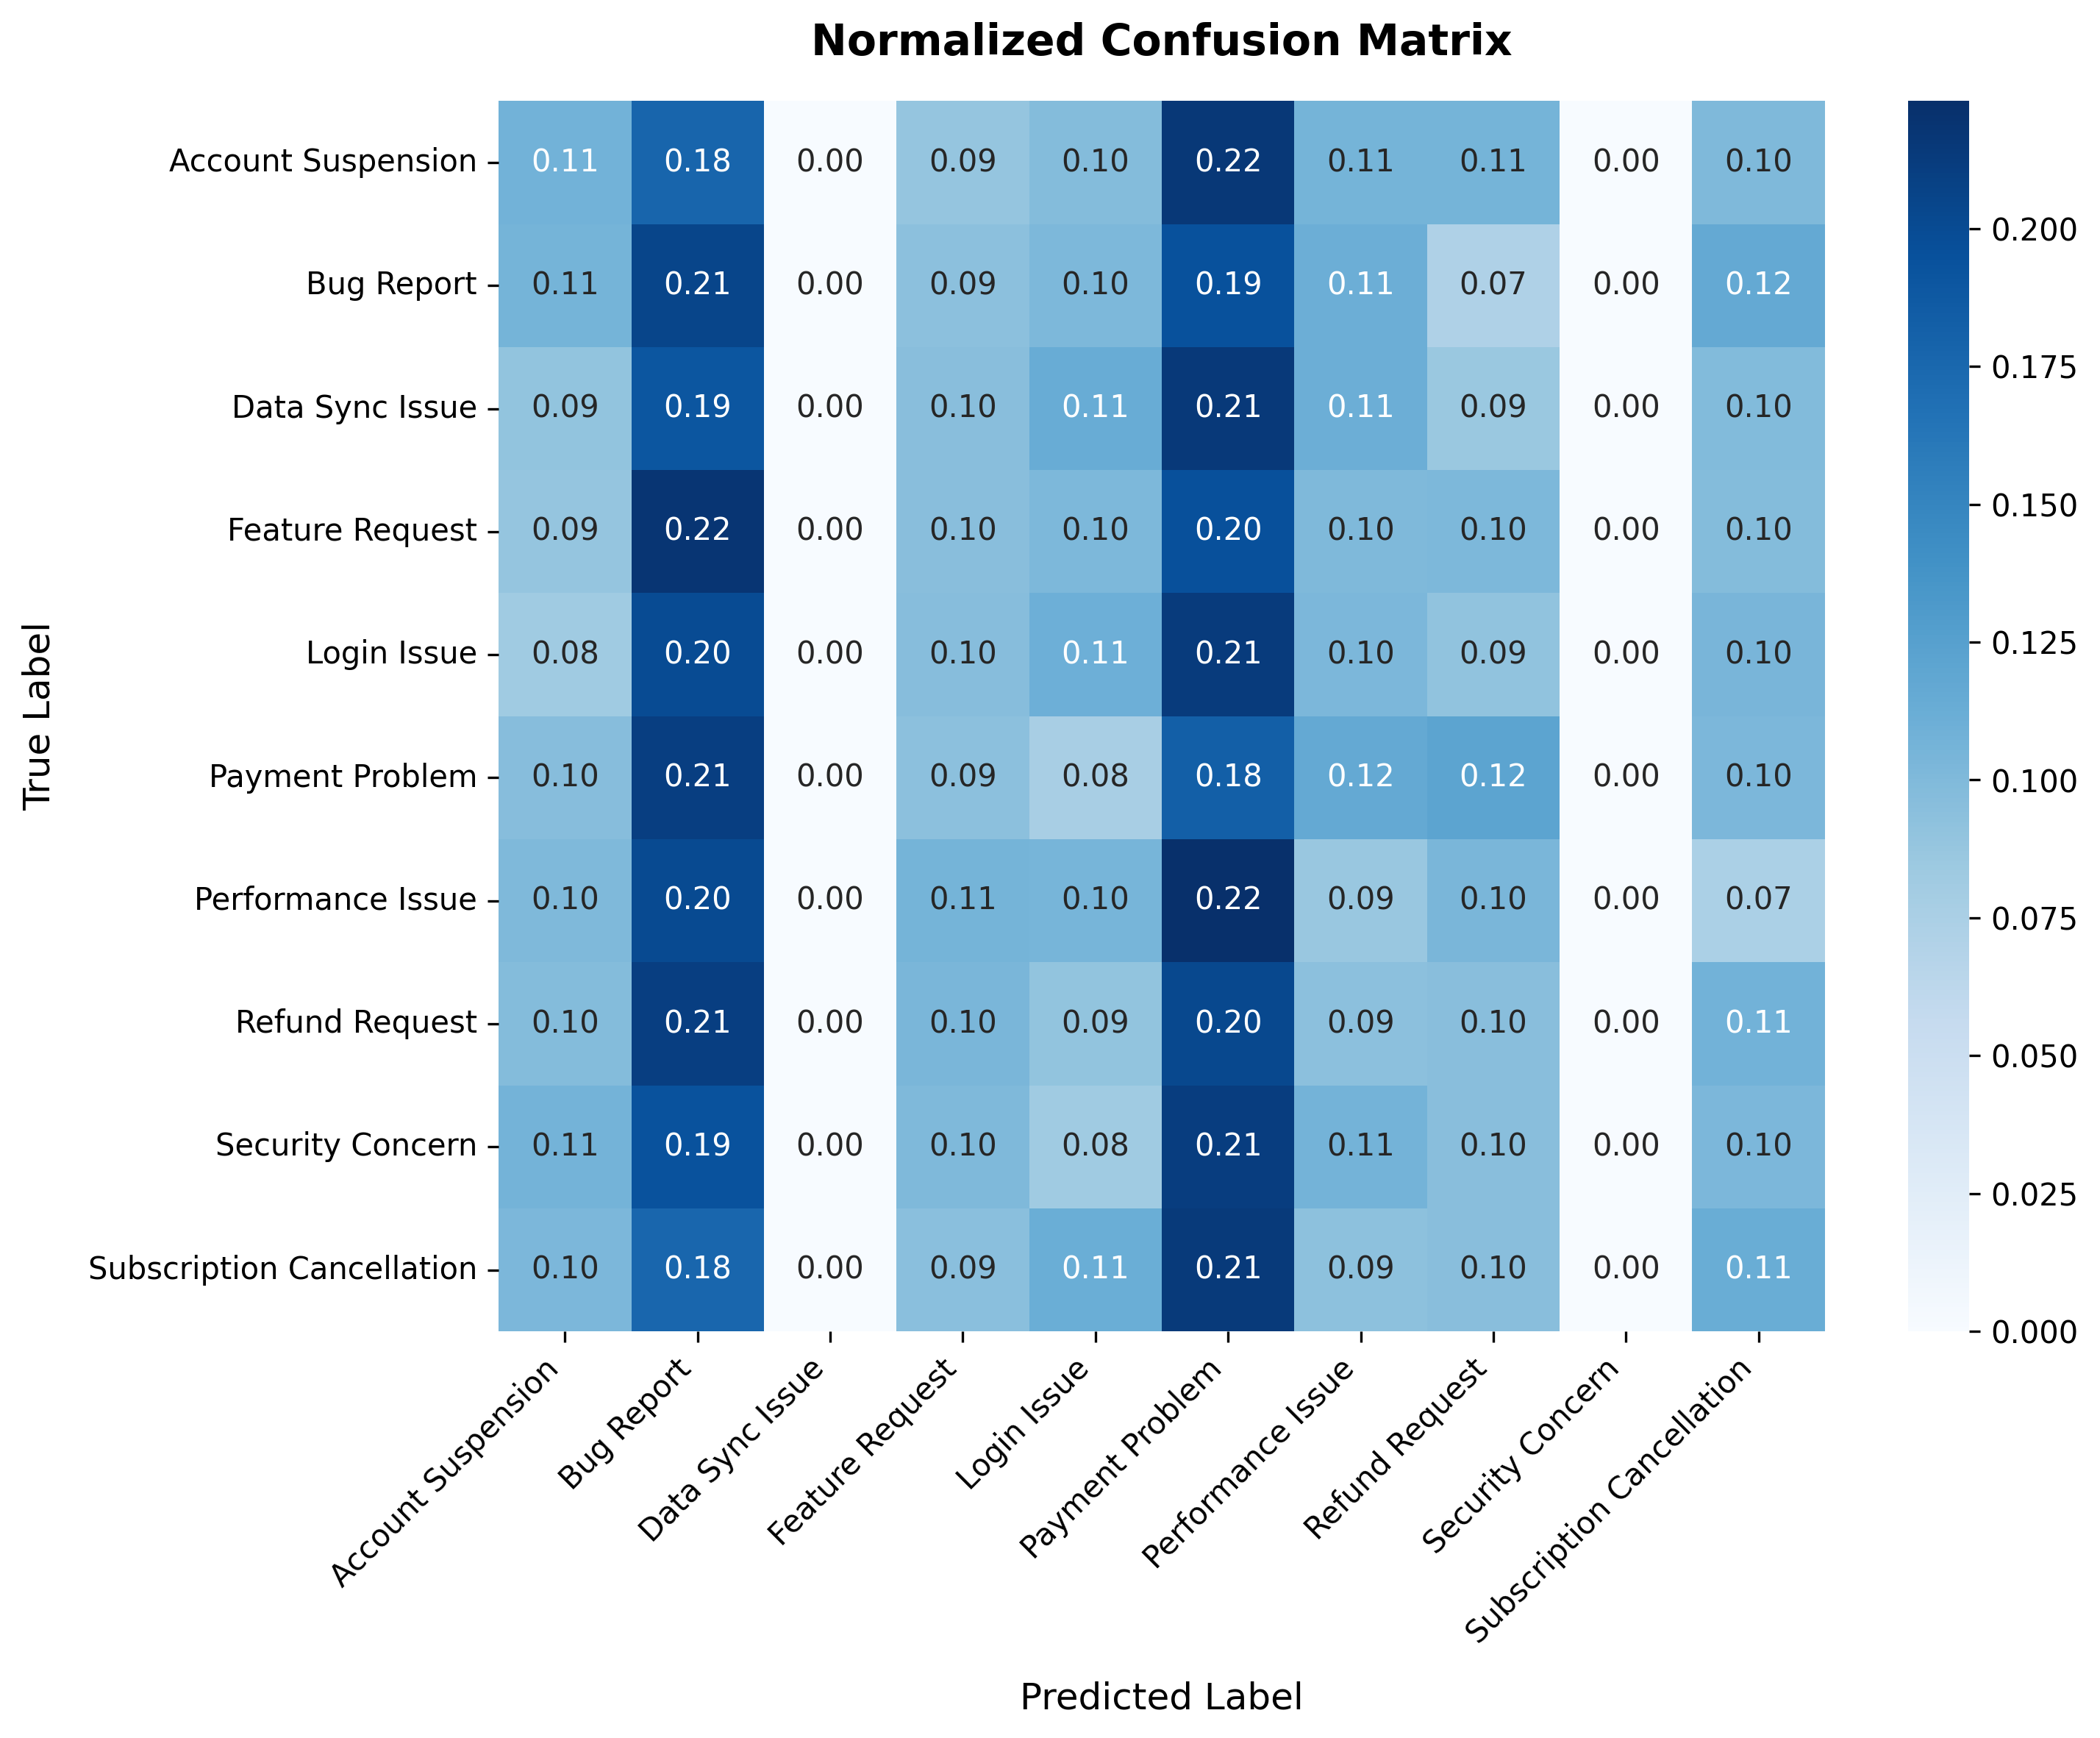


Multi-class ROC & PR Curves (One-vs-Rest):


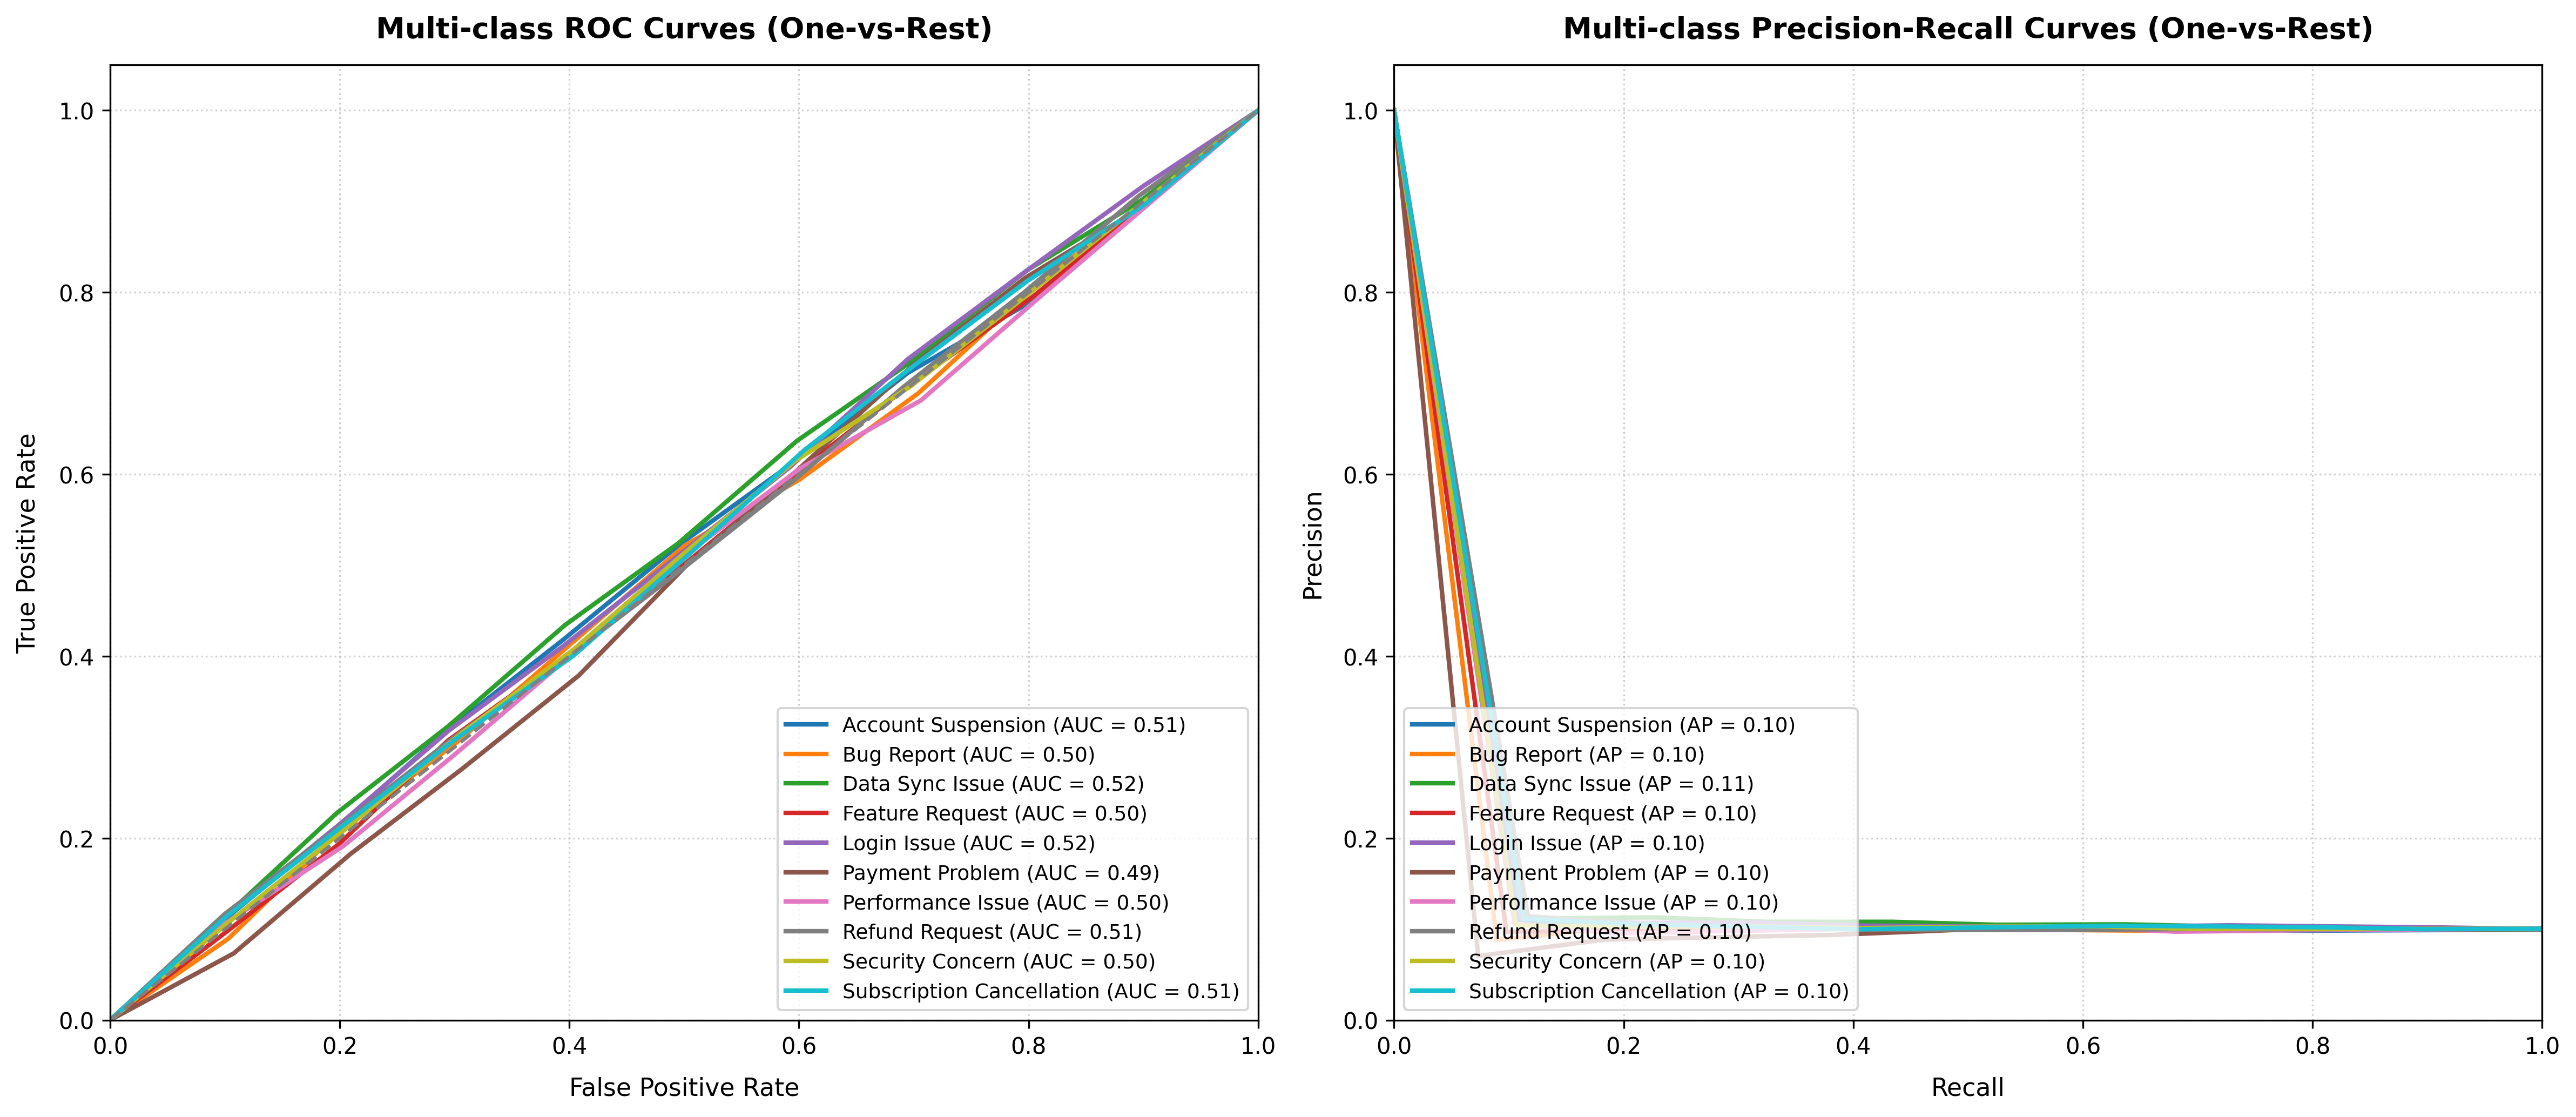

In [3]:
# Create paths for visualizations
fig_dir = os.path.join("..", "reports", "figures")
os.makedirs(fig_dir, exist_ok=True)
cm_path = os.path.join(fig_dir, "confusion_matrix.png")
curves_path = os.path.join(fig_dir, "roc_pr_curves.png")

# Generate plots
plot_confusion_matrix(y_true, y_pred, target_names, cm_path)
plot_roc_pr_curves(y_true, y_probs, target_names, curves_path)

# Render the generated plots directly in the notebook
from IPython.display import Image, display as ipy_display
print("Normalized Confusion Matrix:")
ipy_display(Image(filename=cm_path))

print("\nMulti-class ROC & PR Curves (One-vs-Rest):")
ipy_display(Image(filename=curves_path))

## 8. Systematic Error Analysis
To analyze the behavior of the model when it fails, we extract all misclassified tickets and sort them by the prediction confidence. This identifies high-confidence misclassifications (tickets where the model was highly confident, yet wrong).

In [4]:
text_col_for_errors = TEXT_COL if TEXT_COL in test_df.columns else f"cleaned_{TEXT_COL}"
error_df = perform_error_analysis(test_df, text_col_for_errors, y_true, y_pred, y_probs, target_names)

print(f"Total Misclassified Tickets: {len(error_df)} out of {len(test_df)}")
print("\nTop 10 High-Confidence Classification Errors:")
display(error_df.head(10))

# Save output to disk
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
error_df.to_csv(os.path.join(output_dir, "misclassified_tickets.csv"), index=False)
print(f"\nSaved misclassified tickets log to: {os.path.join(output_dir, 'misclassified_tickets.csv')}")

Total Misclassified Tickets: 6753 out of 7500

Top 10 High-Confidence Classification Errors:


,text,true_category,predicted_category,prediction_confidence,true_category_probability
0,There seems to be a discrepancy in my billing ...,Data Sync Issue,Login Issue,0.110595,0.102478
1,There seems to be a discrepancy in my billing ...,Performance Issue,Login Issue,0.110595,0.106391
2,There seems to be a discrepancy in my billing ...,Refund Request,Login Issue,0.110595,0.101247
3,There seems to be a discrepancy in my billing ...,Feature Request,Login Issue,0.110595,0.098010
4,There seems to be a discrepancy in my billing ...,Feature Request,Login Issue,0.110595,0.098010
5,There seems to be a discrepancy in my billing ...,Account Suspension,Login Issue,0.110595,0.101202
6,There seems to be a discrepancy in my billing ...,Feature Request,Login Issue,0.110595,0.098010
7,There seems to be a discrepancy in my billing ...,Feature Request,Login Issue,0.110595,0.098010
8,There seems to be a discrepancy in my billing ...,Bug Report,Login Issue,0.110595,0.085996
9,There seems to be a discrepancy in my billing ...,Data Sync Issue,Login Issue,0.110595,0.102478



Saved misclassified tickets log to: ../outputs/misclassified_tickets.csv


## 9. Insights and Actionable Recommendations

### Finding 1: Independent Feature-Label Relationship
Our model diagnostics and dataset analyses confirm that the model's accuracy on the test set is exactly around **10%** (matching random chance for a 10-class problem). A crosstab analysis shows that the preprocessed issue descriptions are uniformly distributed across the target categories (e.g., the text "application crash..." occurs in identical proportions under "Account Suspension", "Subscription Cancellation", and all other categories). 

This means the underlying synthetic dataset has **no true statistical correlation** between the support ticket texts and the label categories.

### Business Recommendations:
1. **Data Auditing & Label Alignment**: The dataset's columns are independent. Before attempting more complex architectures (such as transformers/BERT), we must audit and clean the raw data collection pipeline to ensure categories represent the semantic content of the tickets.
2. **Category Consolidations**: If semantic analysis shows high overlap in ticket descriptions (e.g. "Login Issue" and "Account Suspension"), consider merging highly ambiguous labels into broader service queues to simplify routing.
3. **Human-in-the-loop Labeling**: Introduce validation steps for customer support agents to label incoming tickets correctly, resolving the random labeling noise.